# DESI QSO Spectra — Data Preparation

Downloads QSO spectra from DESI DR1 via SPARCL, shifts them to the rest frame,
interpolates onto a common wavelength grid, and saves the matrix for PCA.

**Two samples:**
- High-z quasars: `z > 2` (Ly-α forest regime, broad RF coverage)
- Low-z quasars:  `0.5 < z < 1.0` (optical emission lines: Mg II, Hβ, [O III])

**Install:** `pip install astro-datalab sparclclient`

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.convolution import convolve, Gaussian1DKernel
from sparcl.client import SparclClient
from dl import queryClient as qc
import os

os.makedirs('data', exist_ok=True)
os.makedirs('plots', exist_ok=True)

client = SparclClient()

announcement=Data set deprecation notice: on November 19, 2025 the SDSS/BOSS DR16 data sets were deprecated. Please use the new SDSS/BOSS DR17 data sets instead.


## 1. Query DESI DR1 — two redshift samples

`random_id BETWEEN 0 AND 1` selects 1% of the full QSO catalog — enough for PCA.

In [2]:
def query_qso(z_min, z_max, random_frac=1.0):
    """Query DESI DR1 for main-survey QSOs in a redshift range."""
    sql = f"""
        SELECT zp.targetid, zp.z
        FROM desi_dr1.zpix AS zp
        WHERE zp.survey='main' AND zp.spectype='QSO'
          AND zp.main_primary
          AND zp.zwarn = 0
          AND zp.z BETWEEN {z_min} AND {z_max}
          AND zp.random_id BETWEEN 0 AND {random_frac}
    """
    cat = qc.query(sql=sql, fmt='table')
    print(f'z=[{z_min},{z_max}]: {len(cat)} QSOs found')
    return cat

cat_highz = query_qso(z_min=2.0,  z_max=4.0,  random_frac=1.0)
cat_lowz  = query_qso(z_min=0.5,  z_max=1.0,  random_frac=1.0)

z=[2.0,4.0]: 5165 QSOs found
z=[0.5,1.0]: 1950 QSOs found


## 2. Retrieve spectra via SPARCL

In [3]:
INC = ['specid', 'redshift', 'flux', 'wavelength', 'redshift_warning']

def retrieve_spectra(catalog, max_spectra=500):
    """
    Retrieve up to max_spectra spectra from SPARCL.
    Returns list of (wavelength, flux, redshift) tuples.
    """
    ids  = catalog['targetid'].data.tolist()[:max_spectra]
    out  = []
    # Retrieve in batches of 50 to avoid timeouts
    batch = 50
    for i in range(0, len(ids), batch):
        res = client.retrieve_by_specid(
            specid_list   = ids[i:i+batch],
            include       = INC,
            dataset_list  = ['DESI-DR1']
        )
        for r in res.records:
            if r.redshift_warning == 0:
                out.append((np.array(r.wavelength),
                            np.array(r.flux),
                            r.redshift))
        print(f'  Retrieved {min(i+batch, len(ids))}/{len(ids)}', end='\r')
    print(f'\nDone: {len(out)} spectra')
    return out

spectra_highz = retrieve_spectra(cat_highz, max_spectra=500)
spectra_lowz  = retrieve_spectra(cat_lowz,  max_spectra=300)

  Retrieved 500/500
Done: 515 spectra
  Retrieved 300/300
Done: 315 spectra


## 3. Preview raw spectra (observer frame)

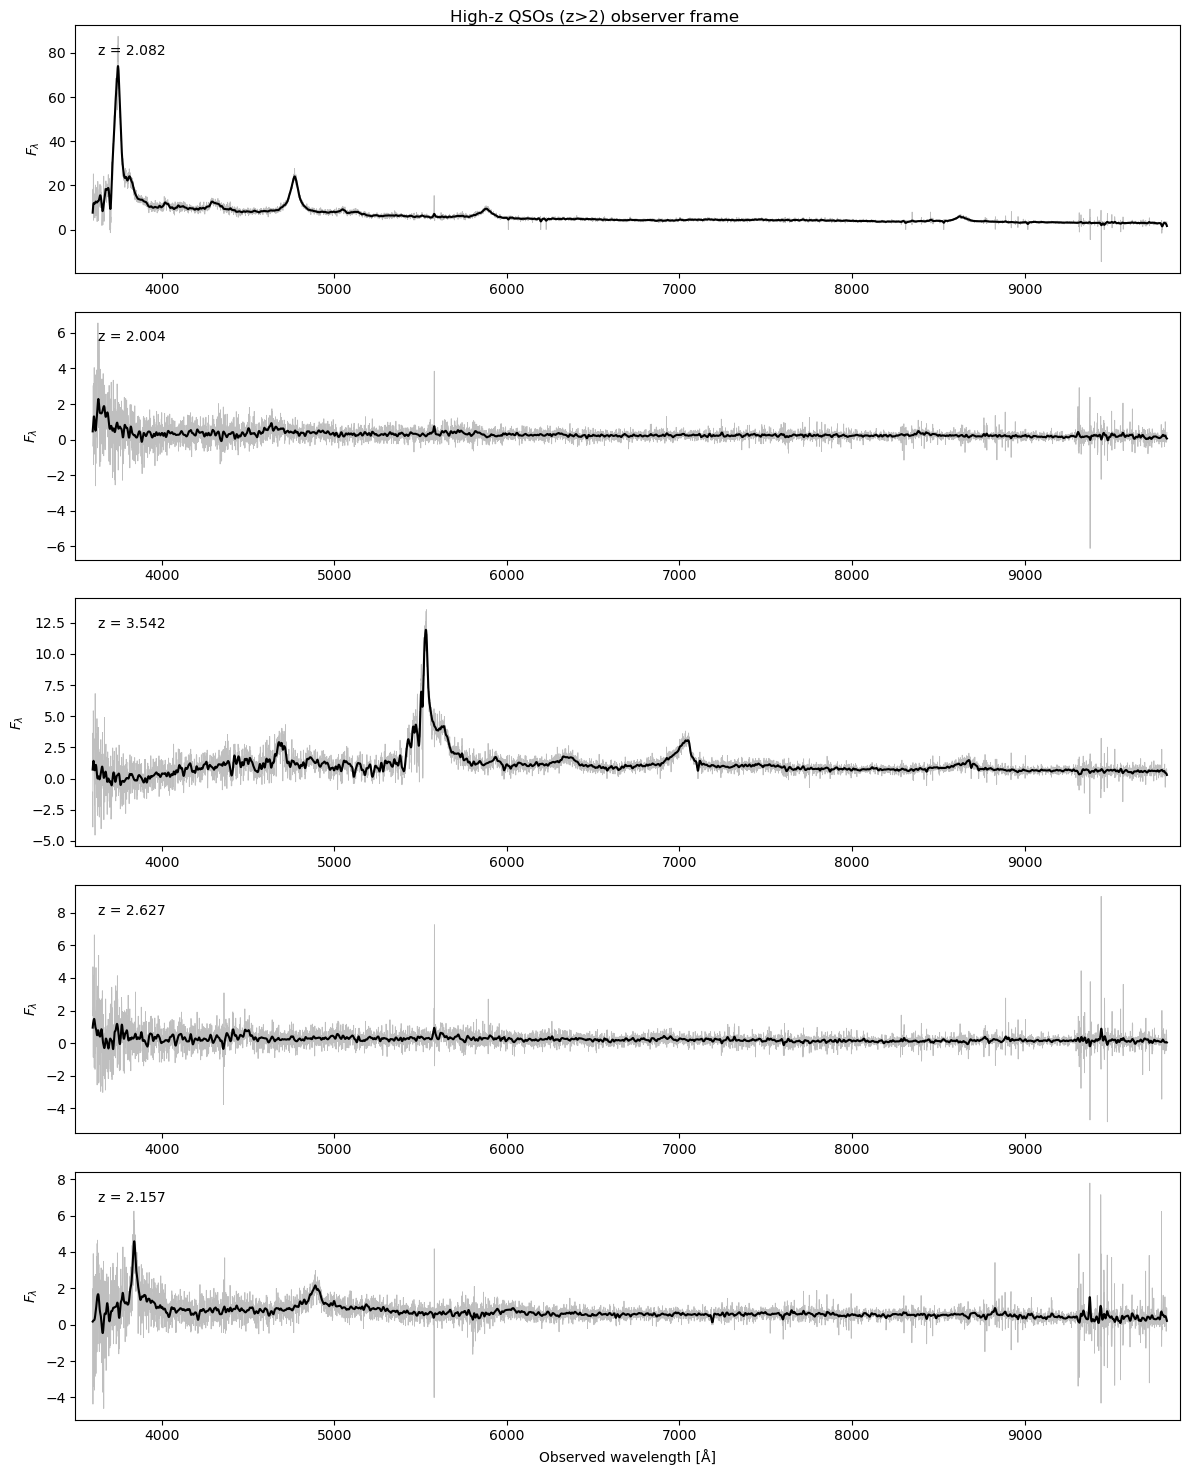

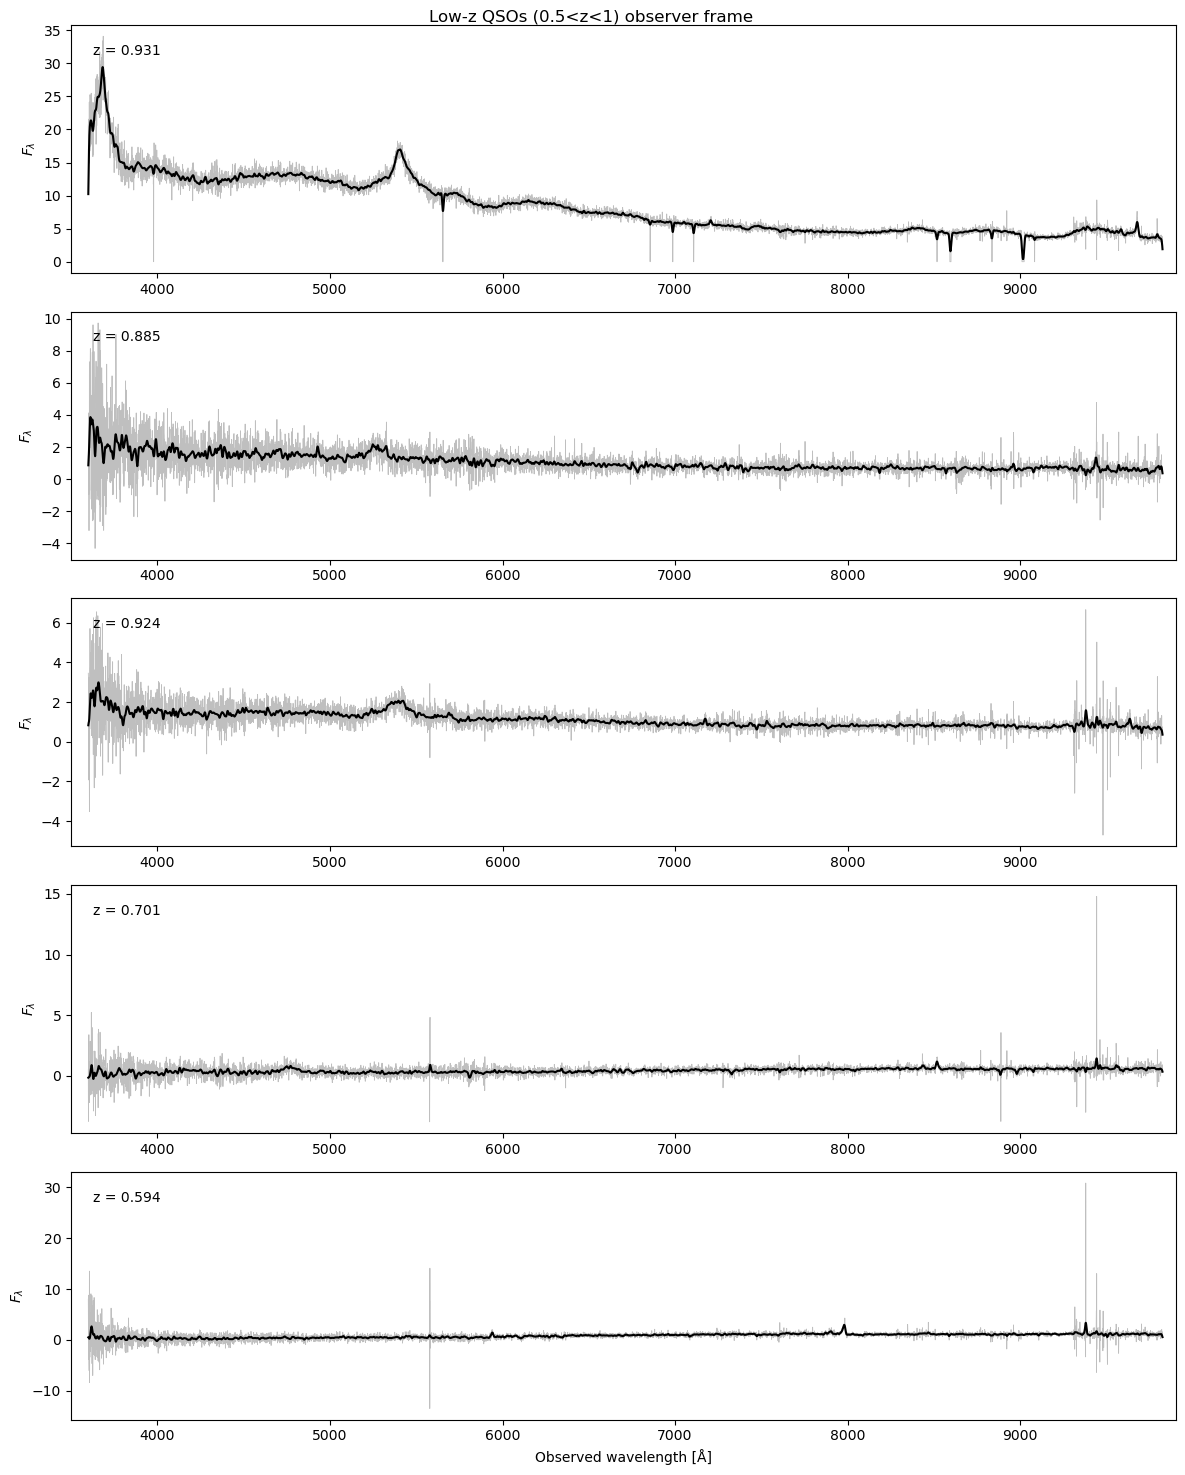

In [4]:
def plot_raw(spectra, n=5, title=''):
    fig, axes = plt.subplots(n, 1, figsize=(12, 3*n), sharex=False)
    for i, (lam, flam, z) in enumerate(spectra[:n]):
        smooth = convolve(flam, Gaussian1DKernel(5))
        axes[i].plot(lam, flam, color='gray', alpha=0.5, lw=0.6)
        axes[i].plot(lam, smooth, 'k', lw=1.5)
        axes[i].set_ylabel(r'$F_\lambda$')
        axes[i].text(0.02, 0.88, f'z = {z:.3f}',
                     transform=axes[i].transAxes, fontsize=10)
        axes[i].set_xlim(3500, 9900)
    axes[-1].set_xlabel(r'Observed wavelength [Å]')
    fig.suptitle(title, fontsize=12)
    plt.tight_layout()
    plt.savefig(f'plots/raw_{title.replace(" ","_")}.png', dpi=120, bbox_inches='tight')
    plt.show()

plot_raw(spectra_highz, n=5, title='High-z QSOs (z>2) observer frame')
plot_raw(spectra_lowz,  n=5, title='Low-z QSOs (0.5<z<1) observer frame')

## 4. Rest-frame shift and common grid interpolation

Each spectrum is shifted to the rest frame: $\lambda_{\rm RF} = \lambda_{\rm obs} / (1+z)$.

Then all spectra are interpolated onto a common rest-frame grid so they can be
stacked into a matrix for PCA. Only the region covered by **all** spectra is kept.

For high-z QSOs (`z > 2`) the RF range 900–2000 Å is well covered (Ly-α, C IV, C III]).
For low-z QSOs (`0.5 < z < 1`) we use 2500–4800 Å (Mg II, Hβ, [O III]).

In [7]:
def to_restframe_grid(spectra, lam_min, lam_max, n_pixels=1000):
    """
    Shift spectra to rest frame and interpolate onto a common grid.
    Spectra with bad coverage or NaNs are dropped.
    Returns: (grid, matrix, redshifts)
    """
    grid = np.linspace(lam_min, lam_max, n_pixels)
    matrix, zs = [], []

    for lam_obs, flam, z in spectra:
        lam_rf = lam_obs / (1.0 + z)

        # Check that this spectrum covers the full grid
        if lam_rf.min() > lam_min or lam_rf.max() < lam_max:
            continue

        # Interpolate onto common grid
        f_interp = np.interp(grid, lam_rf, flam)

        # Skip spectra with NaNs or all-zero flux
        if not np.all(np.isfinite(f_interp)) or np.all(f_interp == 0):
            continue

        # Normalize to median flux (removes overall amplitude differences)
        med = np.median(np.abs(f_interp))
        if med <= 0: continue
        matrix.append(f_interp / med)
        zs.append(z)

    print(f'Grid {lam_min}–{lam_max} Å: {len(matrix)} spectra kept')
    return grid, np.array(matrix), np.array(zs)

# High-z: Ly-α forest + broad emission lines in rest-frame UV
grid_hi, matrix_hi, z_hi = to_restframe_grid(spectra_highz,
                                              lam_min=900, lam_max=2000)

# Low-z: ajustamos el rango RF a lo que realmente cubre DESI para z in [0.5, 1.0]
# obs range ~3600-9800 Å → RF range: 3600/1+z_max – 9800/1+z_min = 1800–6533 Å
# Usamos 2500–4800 Å que está cubierto por todos los espectros del rango z
grid_lo, matrix_lo, z_lo = to_restframe_grid(spectra_lowz,
                                              lam_min=2500, lam_max=4800)

Grid 900–2000 Å: 58 spectra kept
Grid 2500–4800 Å: 315 spectra kept


## 5. Preview rest-frame spectra

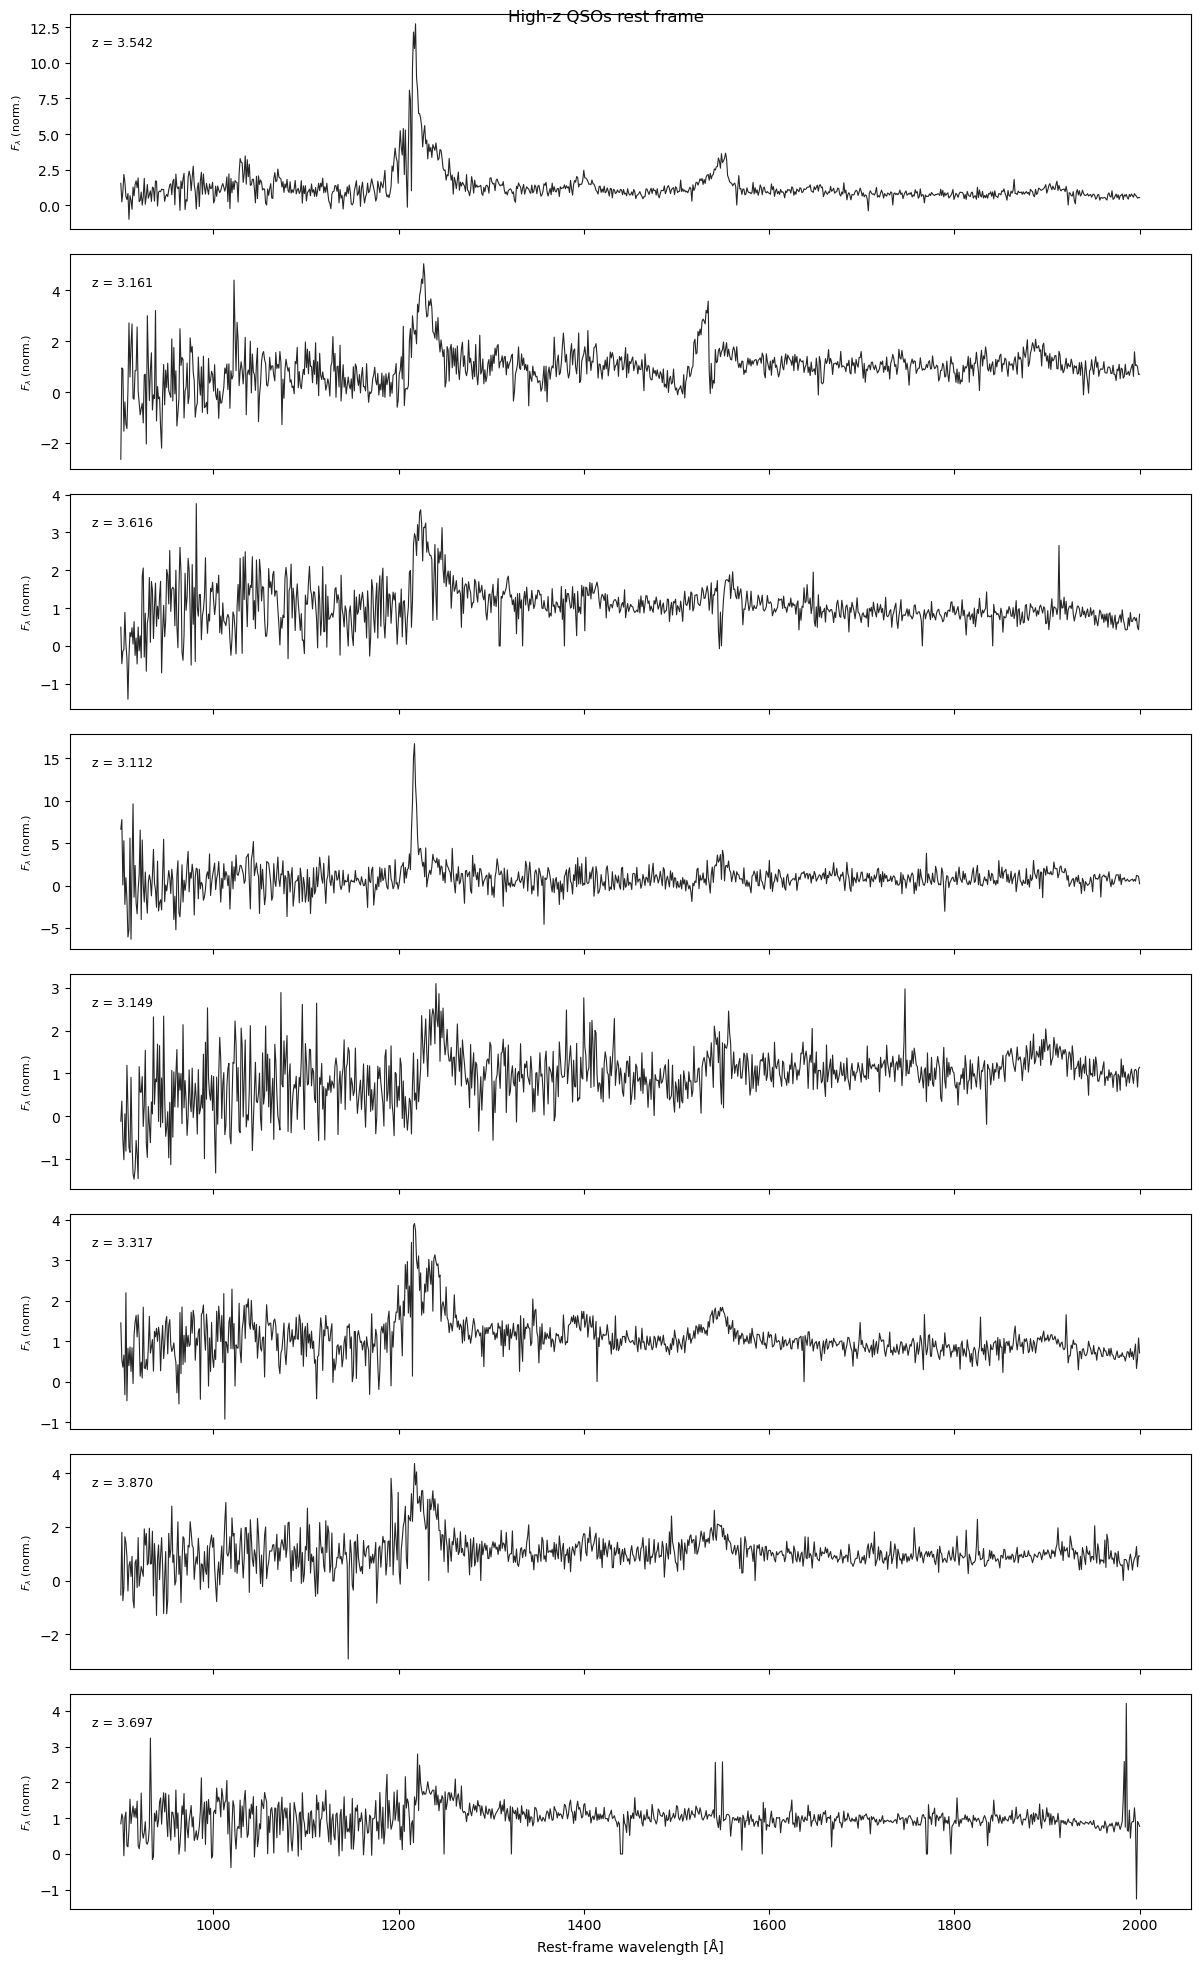

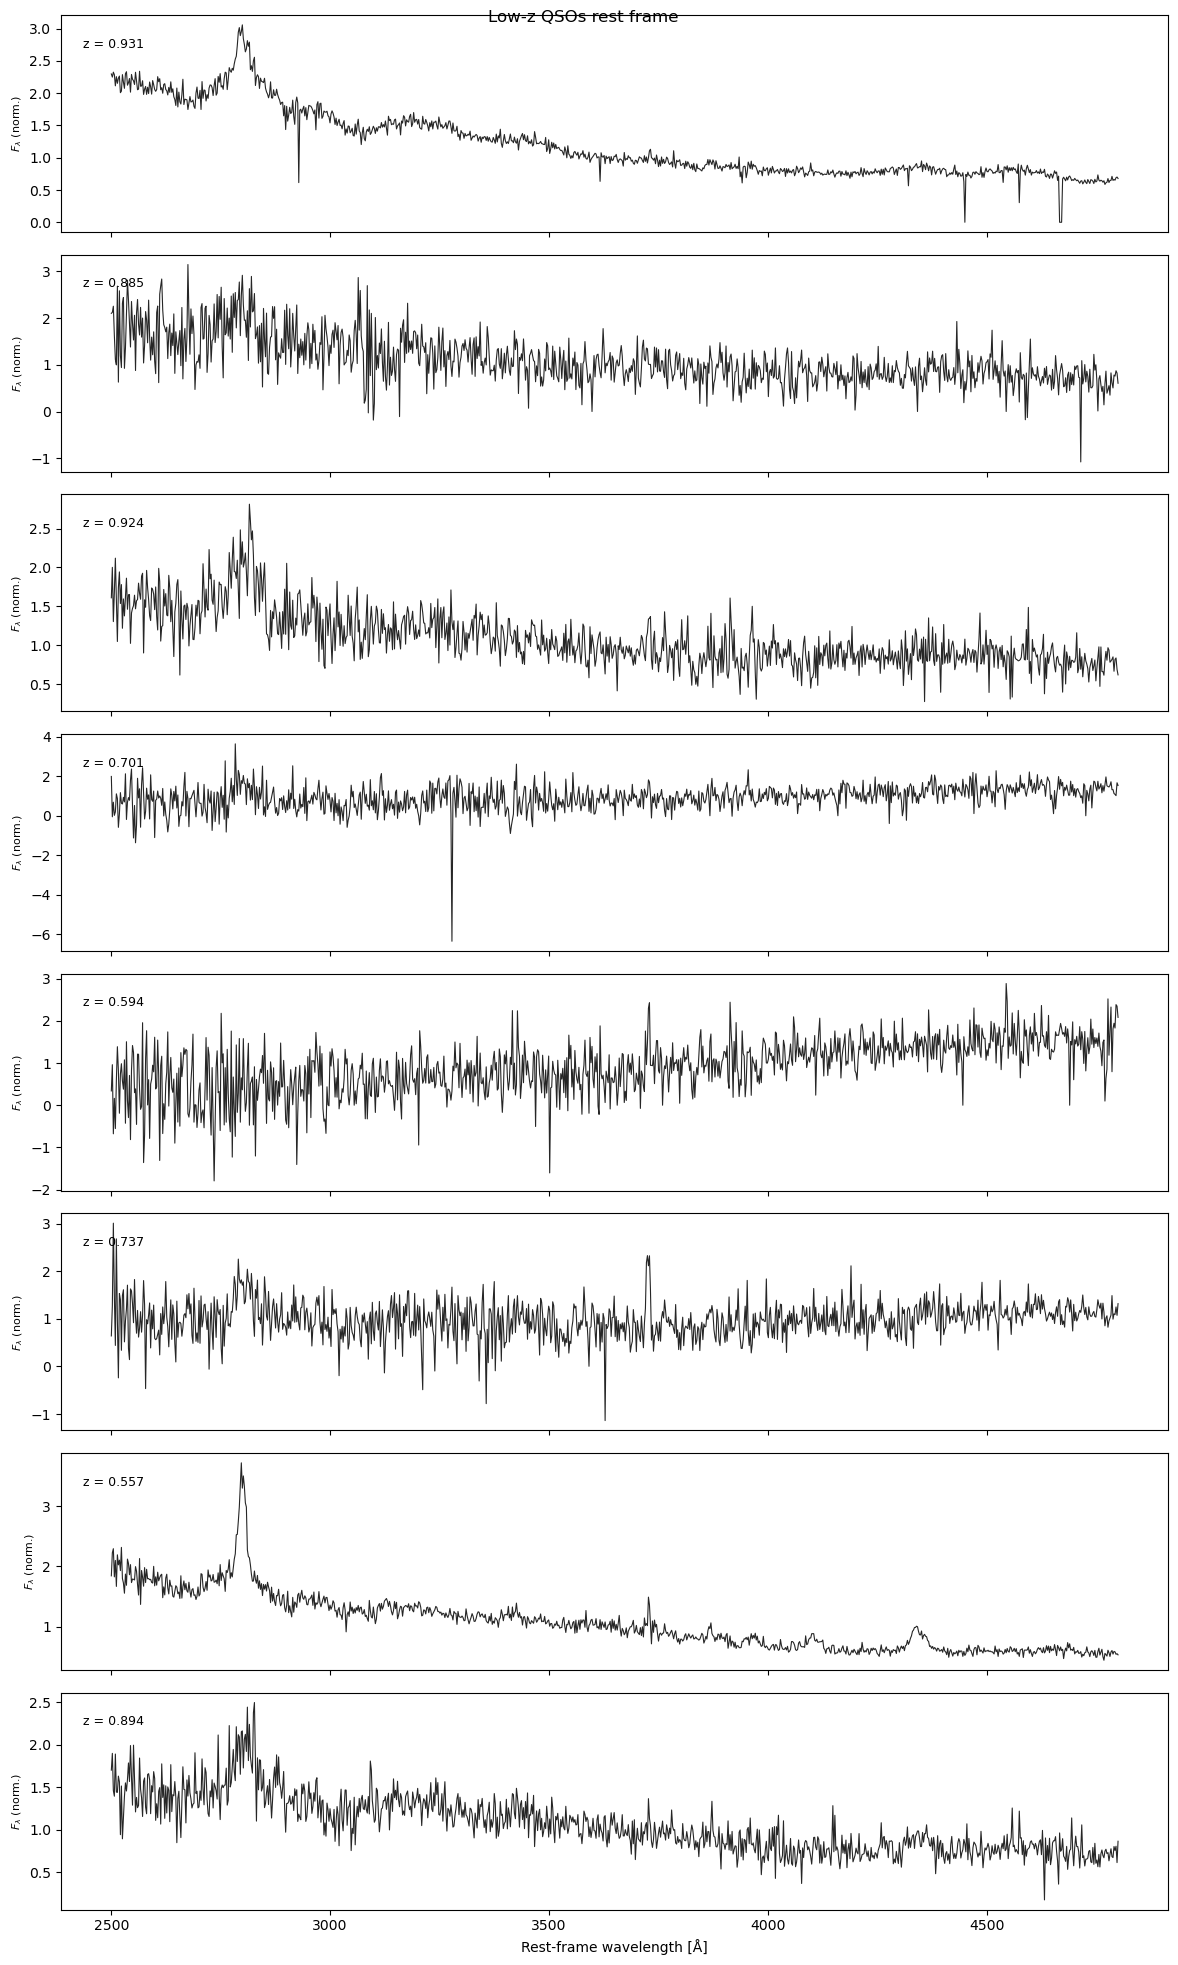

In [8]:
def plot_restframe(grid, matrix, zs, n=8, title=''):
    fig, axes = plt.subplots(n, 1, figsize=(12, 2.5*n), sharex=True)
    for i in range(n):
        axes[i].plot(grid, matrix[i], 'k', lw=0.8, alpha=0.85)
        axes[i].set_ylabel(r'$F_\lambda$ (norm.)', fontsize=8)
        axes[i].text(0.02, 0.85, f'z = {zs[i]:.3f}',
                     transform=axes[i].transAxes, fontsize=9)
    axes[-1].set_xlabel(r'Rest-frame wavelength [Å]')
    fig.suptitle(title, fontsize=12)
    plt.tight_layout()
    plt.savefig(f'plots/restframe_{title.replace(" ","_")}.png',
                dpi=120, bbox_inches='tight')
    plt.show()

plot_restframe(grid_hi, matrix_hi, z_hi, n=8, title='High-z QSOs rest frame')
plot_restframe(grid_lo, matrix_lo, z_lo, n=8, title='Low-z QSOs rest frame')

## 6. Save matrices for PCA notebook

In [9]:
np.save('data/qso_highz_grid.npy',   grid_hi)
np.save('data/qso_highz_matrix.npy', matrix_hi)
np.save('data/qso_highz_z.npy',      z_hi)

np.save('data/qso_lowz_grid.npy',    grid_lo)
np.save('data/qso_lowz_matrix.npy',  matrix_lo)
np.save('data/qso_lowz_z.npy',       z_lo)

print(f'Saved high-z: {matrix_hi.shape}  low-z: {matrix_lo.shape}')

Saved high-z: (58, 1000)  low-z: (315, 1000)


## 7. Visual inspection for the accuracy of the spectra-targetID

As I did not include the TargetID in the plots, it is faster to find it in as in the following cell.
Check the accuracy of the spectra by setting the TargetID in the legacysurvey webpage: https://www.legacysurvey.org/viewer/desi-spectrum/dr1/targetid39627831214349279 

In [15]:
# Find exact match or closest
z_target = 0.5568

# Method 1: Direct filtering
matches = cat_lowz[np.abs(cat_lowz['z'] - z_target) < 0.01]
if len(matches) > 0:
    print(f"targetid: {matches['targetid'][0]}, z={matches['z'][0]:.4f}")

# Method 2: Get closest match regardless of tolerance
idx = np.abs(cat_lowz['z'] - z_target).argmin()
print(f"Closest: targetid={cat_lowz['targetid'][idx]}, z={cat_lowz['z'][idx]:.4f}")

targetid: 39627831214349279, z=0.5568
Closest: targetid=39627831214349279, z=0.5568
